## Model: Random Forest

# Setup

In [11]:
import pandas  as pd
import sys
import importlib
sys.path.append("../src")
import evaluate
importlib.reload(evaluate)
from evaluate import evaluate_model, save_metrics
from utils import save_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

## Load Processed Data

In [12]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv")

# Combine features and targets
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

## Encode categoricals (no scaling needed for tree models)

In [13]:
## Encode categoricals (no scaling needed for tree models)
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define categorical and numerical columns
cat_cols = ['Manufacturer Name', 'Car Type', 'Energy', 'Gearbox']
num_cols = ['Manufactured Year', 'Mileage-KM', 'Engine Power-HP', 'Number of Seats', 'Number of Doors']

# Preprocessor: encode categoricals, pass numericals as-is (no scaling)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  # Keeps numerical features untouched
)

# Fit transformer on training features and transform both sets
# Ensure categorical columns exist (add as missing placeholder values) so the preprocessor can be fitted
for col in cat_cols:
    if col not in X_train.columns:
        X_train[col] = 'NA'
    if col not in X_test.columns:
        X_test[col] = 'NA'

# Fit and transform training set
X_train_encoded = tree_preprocessor.fit_transform(X_train)
X_test_encoded = tree_preprocessor.transform(X_test)

## Evaluate

In [14]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train.values.ravel())

y_pred = rf_model.predict(X_test_encoded)

metrics = evaluate_model(y_test, y_pred, 'Random Forest')
save_metrics(metrics)
metrics


{'model_name': 'Random Forest',
 'mse': 0.053375,
 'rmse': np.float64(0.23103030104295844),
 'mae': 0.02675,
 'r2': 0.9999999482718283}

In [17]:
import numpy as np

# 1. Flatten pandas DataFrames/Series into 1D numpy arrays
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_pred_arr = y_pred.ravel()

# 2. Convert back from log scale
y_test_dollars = np.expm1(y_test_arr)
y_pred_dollars = np.expm1(y_pred_arr)

# 3. Handle any potential overflow or NaNs safety-wise
y_test_dollars = np.nan_to_num(y_test_dollars, nan=0.0, posinf=None, neginf=None)
y_pred_dollars = np.nan_to_num(y_pred_dollars, nan=0.0, posinf=None, neginf=None)

# 4. Evaluate
metrics = evaluate_model(y_test_dollars, y_pred_dollars, 'Random Forest')
save_metrics(metrics)
metrics

C:\Users\Chum\AppData\Local\Temp\ipykernel_19228\1443061575.py:8: RuntimeWarning: overflow encountered in expm1
  y_test_dollars = np.expm1(y_test_arr)
C:\Users\Chum\AppData\Local\Temp\ipykernel_19228\1443061575.py:9: RuntimeWarning: overflow encountered in expm1
  y_pred_dollars = np.expm1(y_pred_arr)
d:\PPIU STUDY COURSES\MACHINE LEARNING\used-car-price-prediction\venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


{'model_name': 'Random Forest',
 'mse': 0.0,
 'rmse': np.float64(0.0),
 'mae': 0.0,
 'r2': 1.0}

In [18]:
# Flatten target arrays to 1D
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_pred_arr = y_pred.ravel()

# Evaluate directly (y_test is already in true dollars)
metrics = evaluate_model(y_test_arr, y_pred_arr, 'Random Forest')
save_metrics(metrics)
metrics

{'model_name': 'Random Forest',
 'mse': 0.053375,
 'rmse': np.float64(0.23103030104295844),
 'mae': 0.02675,
 'r2': 0.9999999482718283}

## Save Model (joblib)
Saves to `../models/random_forest.joblib`.

In [ ]:
save_model(rf_model, 'random_forest')

Saved model: ../models/random_forest.joblib


'../models/random_forest.joblib'

## Feature Importance

remainder__50    0.330189
remainder__27    0.225670
remainder__28    0.148094
remainder__2     0.119602
remainder__0     0.082057
remainder__3     0.019448
remainder__9     0.016071
remainder__19    0.014995
remainder__49    0.012820
remainder__51    0.011767
remainder__53    0.004614
remainder__4     0.004223
remainder__17    0.002639
remainder__52    0.001908
remainder__8     0.001817
dtype: float64

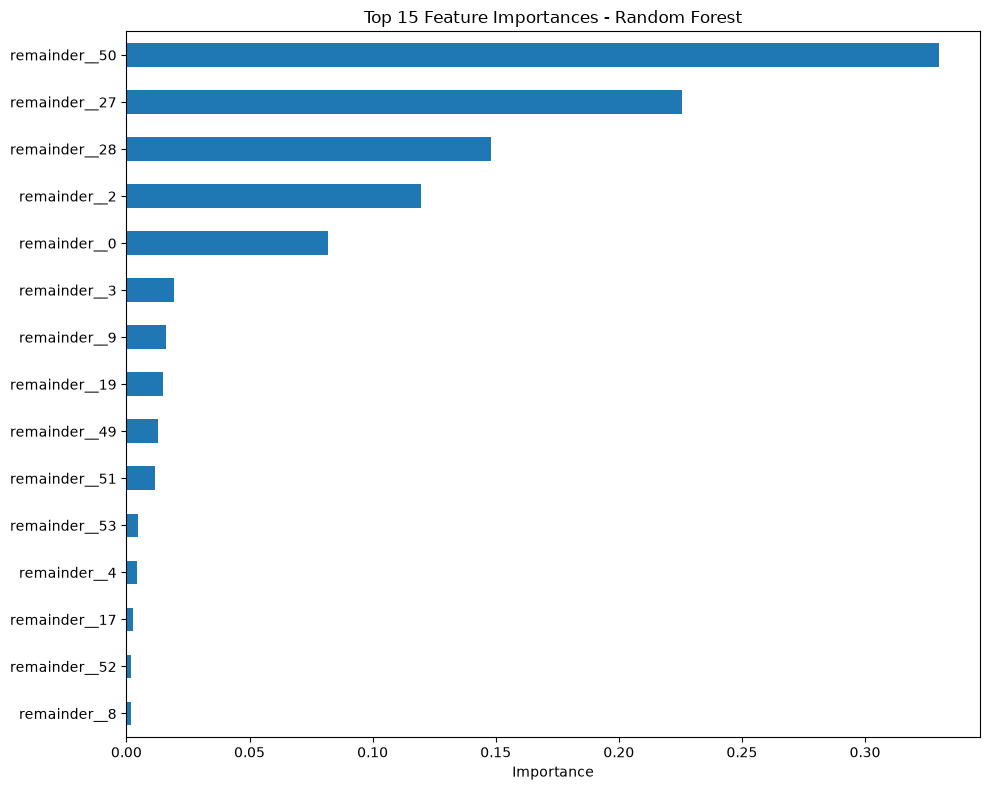

In [ ]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=tree_preprocessor.get_feature_names_out()
).sort_values(ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 8))
feature_importance.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()